<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Flecha_y_cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Flecha y cojinte**

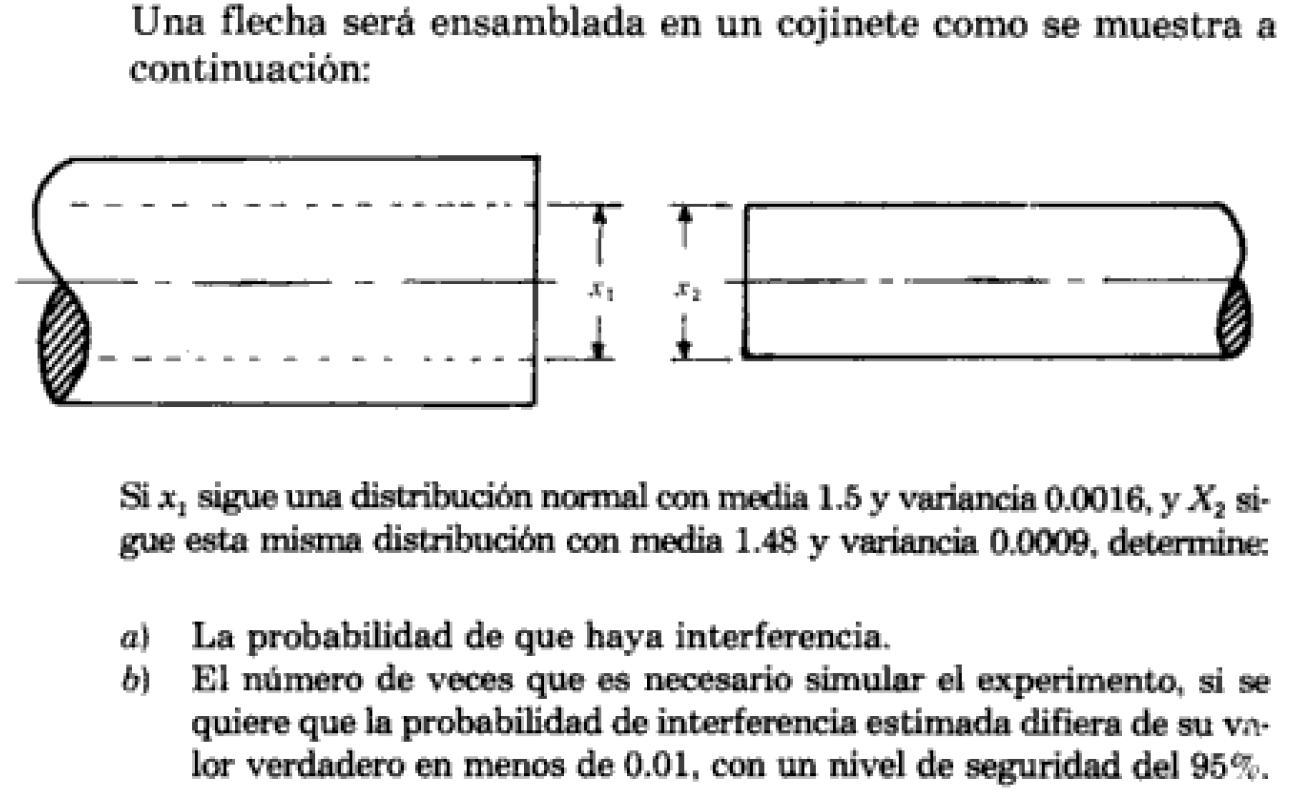

**ANALÍTICAMENTE**

Tenemos un flecha con diámetro $X_1$ y un cojinete con diámetro interior $X_2$ .

Hay interferencia si $X_1 > X_2 $, es decir, si el diámetro de la flecha es mayor que el diámetro del cojinete.

Datos:

$X_1 \sim \mathcal{N}(\mu_1 = 1.5, \sigma_1^2 = 0.0016) \quad \Rightarrow \quad \sigma_1 = 0.04$

$X_2 \sim \mathcal{N}(\mu_2 = 1.48, \sigma_2^2 = 0.0009) \quad \Rightarrow \quad \sigma_2 = 0.03$

Se asume independencia entre $X_1$ y$ X_2 $.


**Cálculo analítico de $P(X_1 > X_2)$ **

$D = X_2 - X_1$

Por independencia y normalidad:

$\mu_D = \mu_2 - \mu_ = 1.48 - 1.5 = -0.02$

$\sigma_D^2 = \sigma_1^2 + \sigma_2^2 = 0.0016 + 0.0009 = 0.0025$

$\sigma_D = 0.05$

Entonces:

$D \sim \mathcal{N}(-0.02, 0.05^2)$

La probabilidad de interferencia es:

$P(X_2 > X_1) = P(D > 0)$

Estandarizamos:

$Z = \frac{0 -(- 0.02)}{0.05} = \frac{0.02}{0.05} = 0.4$

$P(D > 0) = P(Z > -0.4) = 1 - \Phi(-0.4)$

$\Phi(0.4) \approx 0.6554$

Por tanto:

$P(Z > 0.4) \approx 1 - 6554 = 0.3446$


* **analítica** para a):

$\boxed{0.3446}$


* b)
**Número de simulaciones requerido**
Para garantizar error menor que (0.01) con 95% de confianza:


$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$

Sustituyendo:

$$n=\frac{(1.96)^20.3446(1-0.3446)}{(0.01)^2}$$


$$n\approx 8676.28$$



** Por simulación**

In [44]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [45]:
def gaussiana(mu,Sigma,n):
   muestra=[]
   for i in range(n):
      Suma=0
      for j in range(12):
         u=r.random()
         Suma=Suma+u

      x=mu + Sigma*(Suma-6)
      muestra.append(x)

   return muestra

In [46]:
# Número de simulaciones
n = 10000

In [47]:
# Generar muestras
X1 = gaussiana(1.5,0.04,n)
X2 = gaussiana(1.48,0.03,n)

In [48]:
# Contar interferencias
interferencia = 0

for i in range(n):
   if X2[i] > X1[i]:
      interferencia += 1

Por simulación

In [49]:
# Probabilidad estimada
p = interferencia/n
print("Probabilidad estimada =")
p

Probabilidad estimada =


0.3411

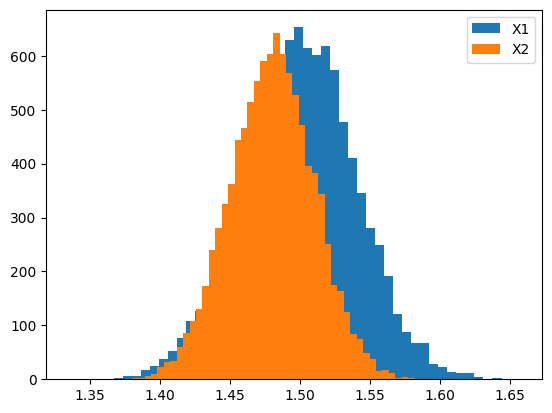

In [50]:
plt.hist(X1,bins=50,label="X1")
plt.hist(X2,bins=50,label="X2")
plt.legend()
plt.show()

Intervalo de confianza de $95\%$

In [51]:
import statsmodels.stats.proportion as smp

# Calcular el intervalo de confianza del 95% para la proporción
# Usamos el método 'wilson' que es robusto para proporciones cercanas a 0 o 1
conf_interval = smp.proportion_confint(count=interferencia, nobs=n, alpha=0.05, method='wilson')
print(f"Intervalo de confianza del 95% para la probabilidad de exceso: [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")

Intervalo de confianza del 95% para la probabilidad de exceso: [0.3319, 0.3505]


**Número de simulaciones requerido**
Para garantizar error menor que (0.01) con 95% de confianza:


$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$


$$n\approx 8721$$

Por eso usar:

$n = 10000$
es suficiente.

In [52]:
m = (1.96**2)*p*(1-p)/(0.01**2)
m

8634.02634864